In [125]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as T
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
import random

import os
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
device


'cuda:0'

In [64]:
def load_tinyimagenet_splits(data_path, n_train=1000, n_cal=500, n_test=2000):
    """
    Restituisce 3 split: train, calibration, test dal dataset Tiny ImageNet
    """
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

    # Carica il dataset completo di training
    full_dataset = datasets.ImageFolder(root=data_path + "train", transform=transform)

    # Permutazione casuale
    perm = torch.randperm(len(full_dataset))

    # Estrazione degli indici per train / cal / test
    idx_train = perm[:n_train]
    idx_cal   = perm[n_train:n_train+n_cal]
    idx_test  = perm[n_train+n_cal:n_train+n_cal+n_test]

    # Estrazione rapida degli esempi
    X_train = torch.stack([full_dataset[i][0] for i in idx_train])
    y_train = torch.tensor([full_dataset[i][1] for i in idx_train])

    X_cal   = torch.stack([full_dataset[i][0] for i in idx_cal])
    y_cal   = torch.tensor([full_dataset[i][1] for i in idx_cal])

    X_test  = torch.stack([full_dataset[i][0] for i in idx_test])
    y_test  = torch.tensor([full_dataset[i][1] for i in idx_test])

    return (X_train, y_train), (X_cal, y_cal), (X_test, y_test)

In [65]:
# Path alla cartella Tiny ImageNet (assicurati che contenga "train" e "val")
data_path = "/home/acarlevaro/Sources/albi/Adversarial_CP_V3/InyImageNet/tiny-imagenet-200/"

# Carica split train / calibration / test
(X_train, y_train), (X_cal, y_cal), (X_test, y_test) = load_tinyimagenet_splits(
    data_path,
    n_train=5000,   # numero di immagini per il train set
    n_cal=2000,     # numero di immagini per il calibration set
    n_test=3000     # numero di immagini per il test set
)

# Controllo dimensioni
print("Train:", X_train.shape, y_train.shape)
print("Calibration:", X_cal.shape, y_cal.shape)
print("Test:", X_test.shape, y_test.shape)

Train: torch.Size([5000, 3, 64, 64]) torch.Size([5000])
Calibration: torch.Size([2000, 3, 64, 64]) torch.Size([2000])
Test: torch.Size([3000, 3, 64, 64]) torch.Size([3000])


In [66]:
class ConvNet(nn.Module):
    def __init__(self):
        super(ConvNet, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=5, stride=2),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.2),
            nn.Conv2d(16, 32, kernel_size=5, stride=2),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.2),
            nn.Conv2d(32, 64, kernel_size=5, stride=2),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.2),
            nn.Conv2d(64, 128, kernel_size=5, stride=2),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.2)
        )
        self.fc_layers = nn.Sequential(
            nn.Linear(128, 1024),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.2),
            nn.Linear(1024, 200)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)
        return x

In [67]:
# Definisci la rete (stessa architettura usata per il training)
net = ConvNet()        # oppure il nn.Sequential equivalente che hai definito
net = net.to(device)   # porta la rete su CPU o GPU

# Carica i pesi salvati
ckptPath = "/home/acarlevaro/Sources/albi/AdversarialCP_old/Verifiably_Robust_CP/VRCP_Classification/Checkpoints/tinynetCNN.pth"


state = torch.load(ckptPath, map_location=device)  # map_location se usi CPU o GPU diversa
net.load_state_dict(state)

# Imposta la rete in modalità eval per evitare dropout/batchnorm training
net.eval()


ConvNet(
  (conv_layers): Sequential(
    (0): Conv2d(3, 16, kernel_size=(5, 5), stride=(2, 2))
    (1): LeakyReLU(negative_slope=0.1)
    (2): Dropout(p=0.2, inplace=False)
    (3): Conv2d(16, 32, kernel_size=(5, 5), stride=(2, 2))
    (4): LeakyReLU(negative_slope=0.1)
    (5): Dropout(p=0.2, inplace=False)
    (6): Conv2d(32, 64, kernel_size=(5, 5), stride=(2, 2))
    (7): LeakyReLU(negative_slope=0.1)
    (8): Dropout(p=0.2, inplace=False)
    (9): Conv2d(64, 128, kernel_size=(5, 5), stride=(2, 2))
    (10): LeakyReLU(negative_slope=0.1)
    (11): Dropout(p=0.2, inplace=False)
  )
  (fc_layers): Sequential(
    (0): Linear(in_features=128, out_features=1024, bias=True)
    (1): LeakyReLU(negative_slope=0.1)
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=1024, out_features=200, bias=True)
  )
)

In [68]:
# Transformazioni per Tiny ImageNet
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Carica il dataset di test / validazione
data_path = "/home/acarlevaro/Sources/albi/Adversarial_CP_V3/InyImageNet/tiny-imagenet-200/"
test_dataset = datasets.ImageFolder(root=data_path + "val", transform=transform)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Calcolo accuracy
correct = 0
total = 0
net.eval()  # già in eval, ma sicuro

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = net(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = correct / total
print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.2962


### BINCP

In [69]:
# %%
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np


device = "cuda" if torch.cuda.is_available() else "cpu"
model = ConvNet().to(device)
model.eval()  # ensure model is in eval mode



ConvNet(
  (conv_layers): Sequential(
    (0): Conv2d(3, 16, kernel_size=(5, 5), stride=(2, 2))
    (1): LeakyReLU(negative_slope=0.1)
    (2): Dropout(p=0.2, inplace=False)
    (3): Conv2d(16, 32, kernel_size=(5, 5), stride=(2, 2))
    (4): LeakyReLU(negative_slope=0.1)
    (5): Dropout(p=0.2, inplace=False)
    (6): Conv2d(32, 64, kernel_size=(5, 5), stride=(2, 2))
    (7): LeakyReLU(negative_slope=0.1)
    (8): Dropout(p=0.2, inplace=False)
    (9): Conv2d(64, 128, kernel_size=(5, 5), stride=(2, 2))
    (10): LeakyReLU(negative_slope=0.1)
    (11): Dropout(p=0.2, inplace=False)
  )
  (fc_layers): Sequential(
    (0): Linear(in_features=128, out_features=1024, bias=True)
    (1): LeakyReLU(negative_slope=0.1)
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=1024, out_features=200, bias=True)
  )
)

In [70]:
import torch
from torch.utils.data import Subset
from torchvision import datasets, transforms
import random

device = "cuda" if torch.cuda.is_available() else "cpu"

# Trasformazioni
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])

# Carica il dataset Tiny ImageNet train
full_trainset = datasets.ImageFolder(root="/home/acarlevaro/Sources/albi/Adversarial_CP_V3/InyImageNet/tiny-imagenet-200/train", transform=transform)

# Scegli un sottoinsieme casuale per calibrazione
n_cal = 1000
subset_indices = random.sample(range(len(full_trainset)), n_cal)
calibration_subset = Subset(full_trainset, subset_indices)

# Estrai X_cal e y_cal come tensori
X_cal = torch.stack([calibration_subset[i][0] for i in range(len(calibration_subset))]).to(device)
y_cal = torch.tensor([calibration_subset[i][1] for i in range(len(calibration_subset))]).to(device)

print(f"X_cal shape: {X_cal.shape}, y_cal shape: {y_cal.shape}")


X_cal shape: torch.Size([1000, 3, 64, 64]), y_cal shape: torch.Size([1000])


In [71]:
# ------------------------------
# Step 3: Define BINCP score function
# ------------------------------
def smoothed_score(model, x, sigma=0.5):
    """Compute nonconformity score on x + epsilon, where epsilon ~ N(0, sigma^2)."""
    epsilon = torch.randn_like(x) * sigma
    logits = model(x + epsilon)
    probs = F.softmax(logits, dim=1)
    # score = 1 - probability of true class
    score = 1 - probs.gather(1, y_cal.view(-1,1)).squeeze()
    return score

In [72]:
# ------------------------------
# Step 4: Calibration
# ------------------------------
sigma = 0.5
scores = smoothed_score(model, X_cal, sigma=sigma)
alpha = 0.1  # desired miscoverage rate
q_hat = np.quantile(scores.detach().cpu().numpy(), 1 - alpha)  # conformal threshold

print(f"Calibration threshold q_hat = {q_hat:.4f}")

Calibration threshold q_hat = 0.9952


In [73]:
# ------------------------------
# Step 5: Prediction / conformal set
# ------------------------------
def conformal_set(model, x, q_hat, sigma=0.5):
    epsilon = torch.randn_like(x) * sigma
    logits = model(x + epsilon)
    probs = F.softmax(logits, dim=1)
    # include all classes with score <= q_hat
    scores = 1 - probs
    sets = [torch.where(s <= q_hat)[0] for s in scores]
    return sets

# Test example
x_test = X_cal[:5]  # example test batch
sets = conformal_set(model, x_test, q_hat, sigma=sigma)
for i, s in enumerate(sets):
    print(f"Example {i} conformal set: {s}")


Example 0 conformal set: tensor([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  14,
         15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,  27,  28,
         29,  30,  31,  32,  33,  34,  35,  36,  38,  39,  40,  41,  42,  43,
         44,  45,  46,  47,  49,  50,  52,  53,  54,  55,  56,  57,  58,  59,
         60,  61,  62,  63,  64,  65,  66,  67,  68,  69,  70,  71,  72,  73,
         74,  75,  76,  77,  78,  80,  81,  82,  83,  84,  86,  87,  88,  90,
         91,  92,  93,  94,  95,  96,  97,  98, 100, 101, 103, 105, 106, 107,
        108, 109, 111, 112, 113, 114, 115, 117, 118, 119, 120, 121, 122, 123,
        124, 125, 126, 127, 128, 130, 131, 132, 133, 134, 135, 136, 137, 138,
        139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 150, 151, 152, 153,
        154, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
        170, 171, 172, 173, 174, 175, 176, 178, 179, 180, 181, 182, 183, 184,
        186, 187, 188, 189, 190, 191, 1

In [109]:
import torch
import torch.nn.functional as F
import time
import numpy as np

def smoothed_score(model, x, sigma=0.12):
    """Compute nonconformity scores on x + epsilon, epsilon ~ N(0, sigma^2)."""
    epsilon = torch.randn_like(x) * sigma
    logits = model(x + epsilon)
    probs = F.softmax(logits, dim=1)
    score = 1 - probs  # shape [1, num_classes]
    return score

def evaluate_conformal_smoothed(model, X_cal, y_cal, X_test, y_test, alpha=0.1, sigma=0.5, device='cuda'): 
    """
    Evaluate smoothed conformal prediction.
    Returns:
    - coverage_mean, coverage_std, coverage_CI95
    - size_mean, size_std, size_CI95
    - time_mean, time_std
    - epsilon
    """
    model.eval()
    model.to(device)

    X_cal, y_cal = X_cal.to(device), y_cal.to(device)
    X_test, y_test = X_test.to(device), y_test.to(device)

    # --------
    # 1. Calibration
    # --------
    cal_scores = []
    with torch.no_grad():
        for i in range(len(X_cal)):
            scores_i = smoothed_score(model, X_cal[i:i+1], sigma=sigma)
            score_true = scores_i[0, y_cal[i]]
            cal_scores.append(score_true.item())

    cal_scores = np.array(cal_scores)
    q_hat = np.quantile(cal_scores, 1 - alpha)

    # --------
    # 2. Test evaluation
    # --------
    coverages = []
    set_sizes = []
    times = []

    with torch.no_grad():
        for i in range(len(X_test)):
            start_time = time.time()
            scores_i = smoothed_score(model, X_test[i:i+1], sigma=sigma)

            conf_set = torch.nonzero(scores_i <= q_hat, as_tuple=False)[:,1]
            end_time = time.time()

            set_sizes.append(len(conf_set))
            times.append(end_time - start_time)

            coverages.append(int(y_test[i].item() in conf_set))

    coverages = np.array(coverages)
    set_sizes = np.array(set_sizes)
    times = np.array(times)

    # --------
    # 3. Compute metrics
    #--------
    coverage_mean = coverages.mean()
    coverage_std  = coverages.std()
    coverage_CI95 = 1.96 * coverage_std / np.sqrt(len(coverages))

    size_mean = set_sizes.mean()
    size_std  = set_sizes.std()
    size_CI95 = 1.96 * size_std / np.sqrt(len(set_sizes))

    time_mean = times.mean()
    time_std  = times.std()

    return (coverage_mean, coverage_std, coverage_CI95,
            size_mean, size_std, size_CI95,
            time_mean, time_std
            )



### Vanilla

In [112]:
(
    coverage_mean, coverage_std, coverage_CI95,
    size_mean, size_std, size_CI95,
    time_mean, time_std
) = evaluate_conformal_smoothed(
        model=net,
        X_cal=X_cal,
        y_cal=y_cal,
        X_test=X_test,
        y_test=y_test,
        alpha=0.1,
        sigma=2*0.03,
        device='cuda:0'
)

print(f"Coverage: {coverage_mean:.3f} ± {coverage_CI95:.3f}")
print(f"Average set size: {size_mean:.3f} ± {size_CI95:.3f}")
print(f"Average time (s): {time_mean:.4f} (std {time_std:.4f})")


Coverage: 0.915 ± 0.010
Average set size: 13.684 ± 0.247
Average time (s): 0.0009 (std 0.0001)


In [113]:
import torch
import torch.nn.functional as F

def pgd_l2(
    model,
    x,
    y,
    epsilon,
    step_size=1/255,
    num_steps=100,
    device="cuda"
):
    """
    L2-constrained PGD attack.
    """
    model.eval()
    x = x.to(device)
    y = y.to(device)

    # Start from the clean point
    x_adv = x.clone().detach()

    # Random initialization (optional but common)
    noise = torch.randn_like(x_adv)
    noise = noise / (noise.view(len(x), -1).norm(dim=1).view(-1,1,1,1) + 1e-8)
    x_adv = (x_adv + epsilon * noise).clone().detach()
    x_adv = x_adv.clamp(0, 1)

    for _ in range(num_steps):
        x_adv.requires_grad_(True)

        logits = model(x_adv)
        loss = F.cross_entropy(logits, y)

        grad = torch.autograd.grad(loss, x_adv)[0]

        # Normalize gradient to L2 unit norm
        grad_norm = grad.view(len(x), -1).norm(dim=1).view(-1,1,1,1)
        grad_unit = grad / (grad_norm + 1e-12)

        # Gradient ascent step
        x_adv = x_adv + step_size * grad_unit

        # Project back to L2 ball
        delta = x_adv - x
        delta_norm = delta.view(len(x), -1).norm(dim=1).view(-1,1,1,1)
        delta = delta * torch.clamp(epsilon / (delta_norm + 1e-12), max=1.0)

        x_adv = (x + delta).clamp(0, 1).detach()

    return x_adv


In [114]:
def generate_pgd_dataset(model, X, y, dataset="cifar10", device="cuda", eps = 0.03):
    #if dataset.lower() == "cifar10":
    #    eps = 0.03
    #elif dataset.lower() in ["cifar100", "tinyimagenet"]:
    #    eps = 0.02
    #else:
    #    raise ValueError("Unknown dataset")

    X_adv_list = []
    batch_size = 64  # adjust as needed

    model.eval()

    print(eps)
    
    for i in range(0, len(X), batch_size):
        xb = X[i:i+batch_size].to(device)
        yb = y[i:i+batch_size].to(device)

        X_adv = pgd_l2(
            model=model,
            x=xb,
            y=yb,
            epsilon=eps,
            step_size=1/255,
            num_steps=100,
            device=device
        )

        X_adv_list.append(X_adv.cpu())

    return torch.cat(X_adv_list, dim=0)


In [115]:
X_test_adv = generate_pgd_dataset(
    model=net,
    X=X_test,
    y=y_test,
    dataset="tinyimagenet",
    device="cuda:0"
)

print("Adversarial dataset shape:", X_test_adv.shape)


0.03
Adversarial dataset shape: torch.Size([3000, 3, 64, 64])


In [122]:
15*0.03

0.44999999999999996

### Attacked

In [127]:
(
    coverage_mean, coverage_std, coverage_CI95,
    size_mean, size_std, size_CI95,
    time_mean, time_std
) = evaluate_conformal_smoothed(
        model=net,
        X_cal=X_cal,
        y_cal=y_cal,
        X_test=X_test_adv,
        y_test=y_test,
        alpha=0.1,
        sigma=2*0.03,
        device='cuda:0'
)

print(f"Coverage: {coverage_mean:.3f} ± {coverage_CI95:.3f}")
print(f"Average set size: {size_mean:.3f} ± {size_CI95:.3f}")
print(f"Average time (s): {time_mean:.4f} (std {time_std:.4f})")

Coverage: 0.502 ± 0.018
Average set size: 17.841 ± 0.171
Average time (s): 0.0008 (std 0.0001)


In [123]:
#def smoothed_score(model, x, y, sigma=0.5):
#    eps = torch.randn_like(x) * sigma
#    logits = model(x + eps)
#    probs = F.softmax(logits, dim=1)
#    return (1 - probs.gather(1, y.view(-1,1)).squeeze()).detach()

def compute_BINCP(model, X_cal, y_cal, X_test, y_test, eps, sigma=0.5, device='cuda:0'):
    """
    Compute BINCP under PGD attack using smoothed conformal evaluation.
    """
    print(eps)
    # 1. Generate PGD-attacked dataset
    X_test_adv = generate_pgd_dataset(
        model, 
        X_test, 
        y_test, 
        dataset="tinyimagenet", 
        device=device, 
        eps=eps
    )
    
    print("sigma",sigma)
    # 2. Evaluate using the unified conformal function
    (coverage_mean, coverage_std, coverage_CI95,
        size_mean, size_std, size_CI95,
        time_mean, time_std
    ) = evaluate_conformal_smoothed(
        model=model,
        X_cal=X_cal,
        y_cal=y_cal,
        X_test=X_test_adv,
        y_test=y_test,
        alpha=0.1,
        sigma=sigma,
        device=device
    )
    
    print("coverage:", coverage_mean)
    print("size:",size_mean)
    
    # 3. Return a dictionary fully compatible with your CSV
    return {
        "epsilon": eps,
        "coverage_mean": coverage_mean,
        "coverage_std": coverage_std,
        "coverage_CI95": coverage_CI95,
        "size_mean": size_mean,
        "size_std": size_std,
        "size_CI95": size_CI95,
        "time_mean": time_mean,
        "time_std": time_std
    }


def bincp_predict_set(model, x, qhat, sigma=0.5):
    x = x.unsqueeze(0)  # single item
    scores = []
    with torch.no_grad():
        for cls in range(200):
            eps = torch.randn_like(x) * sigma
            logits = model(x + eps)
            probs = F.softmax(logits, dim=1)
            scores.append(1 - probs[0, cls].item())
    scores = np.array(scores)
    return (scores <= qhat).astype(int)

In [124]:
epsilons_VRCP = [0.005, 0.01, 0.015, 0.02, 0.025, 0.03, 0.035, 0.04, 0.045, 0.05]
epsilons_extra = np.linspace(0.1, 5.0, 10)
all_eps = list(epsilons_VRCP) + list(epsilons_extra)

results = []
for eps in tqdm.tqdm(all_eps):
    stats = compute_BINCP(
        model,
        X_cal, y_cal,
        X_test, y_test,
        eps=eps,
        sigma=15*eps
    )
    stats["epsilon"] = eps
    results.append(stats)

df = pd.DataFrame(results)
df.to_csv("BINCP_results_TINYIMAGENET.csv", index=False)
print("Saved BINCP_results_TINYIMAGENET.csv!")

  0%|          | 0/20 [00:00<?, ?it/s]

0.005
0.005
sigma 0.075


  5%|▌         | 1/20 [00:13<04:09, 13.14s/it]

coverage: 0.9013333333333333
size: 179.80066666666667
0.01
0.01
sigma 0.15


 10%|█         | 2/20 [00:25<03:49, 12.75s/it]

...

coverage: 0.9166666666666666
size: 182.55666666666667
4.455555555555556
4.455555555555556
sigma 66.83333333333334


 95%|█████████▌| 19/20 [04:04<00:12, 12.91s/it]

coverage: 0.902
size: 181.12466666666666
5.0
5.0
sigma 75.0


100%|██████████| 20/20 [04:17<00:00, 12.86s/it]

coverage: 0.897
size: 179.12766666666667
Saved BINCP_results_TINYIMAGENET.csv!


In [28]:
import numpy as np
import tqdm
import pandas as pd

In [29]:
df = pd.DataFrame(results)
df.to_csv("BINCP_results_TINYIMAGENET.csv", index=False)
print("Saved BINCP_results_TINYIMAGENET.csv!")

Saved BINCP_results_TINYIMAGENET.csv!


In [58]:
df

,coverage_mean,coverage_CI95,size_mean,size_CI95,time_mean,time_CI95,epsilon
0,0.442000,0.017774,13.781667,0.128065,0.000883,0.000002,0.005000
1,0.439333,0.017763,13.677000,0.126522,0.000912,0.000003,0.010000
2,0.437000,0.017753,13.442000,0.124061,0.000877,0.000002,0.015000
3,0.447667,0.017797,14.225667,0.131422,0.000869,0.000007,0.020000
4,0.456667,0.017828,14.771667,0.137043,0.000878,0.000002,0.025000
5,0.443333,0.017780,14.902333,0.139642,0.000872,0.000001,0.030000
6,0.476000,0.017875,17.966333,0.176247,0.000877,0.000002,0.035000
7,0.462667,0.017845,19.299667,0.202784,0.000909,0.000005,0.040000
8,0.458667,0.017834,21.323668,0.243821,0.000933,0.000003,0.045000
9,0.464333,0.017850,25.458334,0.337472,0.000884,0.000007,0.050000


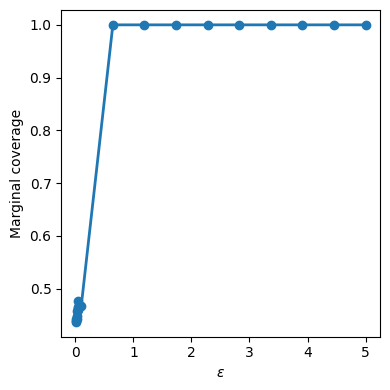

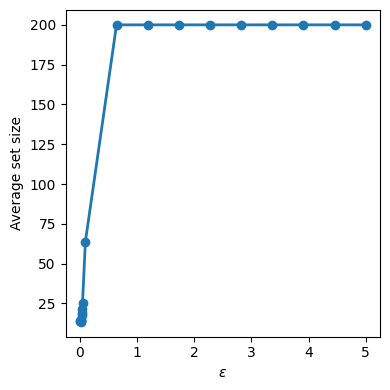

In [59]:
import matplotlib.pyplot as plt
"""
df must contain:
    epsilon, coverage_mean, size_mean
"""

eps = df["epsilon"].values
cov = df["coverage_mean"].values
size = df["size_mean"].values

# ------------------------------------
# 1. PLOT COVERAGE vs EPSILON
# ------------------------------------
plt.figure(figsize=(4,4))
plt.plot(eps, cov, marker="o", linewidth=2)
plt.xlabel(r"$\varepsilon$")
plt.ylabel("Marginal coverage")
plt.tight_layout()
plt.show()

# ------------------------------------
# 2. PLOT AVERAGE SET SIZE vs EPSILON
# ------------------------------------
plt.figure(figsize=(4,4))
plt.plot(eps, size, marker="o", linewidth=2)
plt.xlabel(r"$\varepsilon$")
plt.ylabel("Average set size")
plt.tight_layout()
plt.show()

### RCP1

In [34]:
model = net.eval()

In [35]:
import torch
import torch.nn.functional as F
import math
import time

class RCP1:
    def __init__(self, model, alpha=0.1, sigma=0.5, device='cuda'):
        self.model = model.to(device)
        self.alpha = alpha
        self.sigma = sigma
        self.device = device
        self.threshold = None

    def score(self, x, y=None):
        """Compute smoothed nonconformity score."""
        x = x.to(self.device)
        eps = torch.randn_like(x) * self.sigma
        logits = self.model(x + eps)
        probs = F.softmax(logits, dim=1)

        if y is not None:
            y = y.to(self.device)
            scores = 1 - probs.gather(1, y.view(-1,1)).squeeze()
        else:
            # fallback: score rispetto alla classe predetta
            scores = 1 - probs.max(dim=1).values
        return scores, probs

    def calibrate(self, x_cal, y_cal):
        """Calibrate quantile threshold using calibration set."""
        scores, _ = self.score(x_cal, y_cal)
        scores_sorted = torch.sort(scores)[0]
        n = scores.shape[0]
        k = math.ceil((n + 1) * (1 - self.alpha)) - 1
        k = max(0, min(k, n - 1))
        self.threshold = scores_sorted[k].item()
        return self.threshold

    def predict_multiclass(self, x_test):
        """Return multiclass pred_set [batch, num_classes]."""
        x_test = x_test.to(self.device)
        eps = torch.randn_like(x_test) * self.sigma
        logits = self.model(x_test + eps)
        probs = F.softmax(logits, dim=1)
        # score per ogni classe
        scores = 1 - probs  # shape [batch, num_classes]
        pred_set = scores <= self.threshold  # shape [batch, num_classes]
        return pred_set, probs.argmax(dim=1), scores


In [102]:
def evaluate_cp_multiclass(cp_model, test_X, test_y, device='cuda', num_mc=1):
    test_X = test_X.to(device)
    test_y = test_y.to(device)
    
    n = len(test_X)
    coverages = []
    set_sizes = []
    times_list = []
    
    for i in range(n):
        x = test_X[i].unsqueeze(0)
        y = test_y[i].unsqueeze(0)
        
        start = time.time()
        pred_set, y_hat, scores = cp_model.predict_multiclass(x)
        elapsed = time.time() - start
        
        # Coverage = pred_set contiene la classe vera
        coverage = pred_set[0, y.item()].float().item()
        set_size = pred_set.sum().item()  # numero di classi incluse nel set
        
        coverages.append(coverage)
        set_sizes.append(set_size)
        times_list.append(elapsed)
    
    def mean_ci(values):
        v = torch.tensor(values, dtype=torch.float32)
        mean = v.mean().item()
        ci = 1.96 * v.std(unbiased=True).item() / math.sqrt(len(v))
        return mean, ci
    
    cov_mean, cov_ci = mean_ci(coverages)
    size_mean, size_ci = mean_ci(set_sizes)
    time_mean, time_ci = mean_ci(times_list)
    
    return cov_mean, cov_ci, size_mean, size_ci, time_mean, time_ci


In [132]:
device = torch.device('cuda')

# Istanza CP
cp = RCP1(model, alpha=0.1, sigma=0.01, device=device)

# Calibrazione
cp.calibrate(X_cal.to(device), y_cal.to(device))

# Valutazione
cov_mean, cov_ci, size_mean, size_ci, time_mean, time_ci = evaluate_cp_multiclass(
    cp_model=cp,
    test_X=X_test_adv,
    test_y=y_test,
    device=device
)

print(f"Marginal coverage: {cov_mean:.2f} ± {cov_ci:.2f}")
print(f"Average set size: {size_mean:.2f} ± {size_ci:.2f}")
print(f"Average time: {time_mean:.4f} ± {time_ci:.4f} s")


Marginal coverage: 0.90 ± 0.01
Average set size: 179.76 ± 0.03
Average time: 0.0009 ± 0.0000 s


In [52]:
def evaluate_RCP1_with_attack(cp_model, X_cal, y_cal, X_test, y_test, eps, sigma=0.5, device="cuda"):

    # ---- 1. Attacco PGD L2 ----
    X_test_adv = generate_pgd_dataset(
        model, 
        X_test, 
        y_test, 
        dataset="tinyimagenet", 
        device=device, 
        eps=eps
    ) 

    # ---- 2. Calibrazione ----
    cp_model.sigma = sigma
    cp_model.calibrate(X_cal, y_cal)

    # ---- 3. Valutazione ----
    n = len(X_test_adv)
    coverages = []
    sizes = []
    times_list = []

    for i in range(n):
        x = X_test_adv[i].unsqueeze(0)
        y = y_test[i].unsqueeze(0)

        start = time.time()
        pred_set, y_hat, scores = cp_model.predict_multiclass(x)
        elapsed = time.time() - start

        # Coverage
        coverages.append(pred_set[0, y.item()].float().item())

        # Set size
        sizes.append(pred_set.sum().item())

        # Time
        times_list.append(elapsed)

    # ---- 4. Mean + 95% CI ----
    def mean_ci(vals):
        v = torch.tensor(vals, dtype=torch.float32)
        m = v.mean().item()
        ci = 1.96 * v.std(unbiased=True).item() / math.sqrt(len(vals))
        return m, ci

    cov_mean, cov_ci = mean_ci(coverages)
    size_mean, size_ci = mean_ci(sizes)
    time_mean, time_ci = mean_ci(times_list)
    print("size:",size_mean)

    return {
        "coverage_mean": cov_mean,
        "coverage_CI95": cov_ci,
        "size_mean": size_mean,
        "size_CI95": size_ci,
        "time_mean": time_mean,
        "time_CI95": time_ci,
    }


In [56]:
import pandas as pd
import tqdm
import numpy as np

# Lista epsilon come nel tuo esempio
epsilons_VRCP = [0.005, 0.01, 0.015, 0.02, 0.025, 0.03, 0.035, 0.04, 0.045, 0.05]
epsilons_extra = np.linspace(0.1, 5.0, 10)
all_eps = list(epsilons_VRCP) + list(epsilons_extra)

results = []

# Inizializza il tuo CP model
cp = RCP1(net, alpha=0.1, sigma=0.05, device=device)

for eps in tqdm.tqdm(all_eps):
    stats = evaluate_RCP1_with_attack(
        cp, 
        X_cal, y_cal,
        X_test, y_test,
        eps=eps,
        sigma=2*eps
    )
    stats["epsilon"] = eps
    results.append(stats)

df = pd.DataFrame(results)
df.to_csv("RCP1_results.csv", index=False)
print("Saved RCP1_results.csv!")


  0%|          | 0/20 [00:00<?, ?it/s]

0.005


  5%|▌         | 1/20 [00:12<04:02, 12.74s/it]

size: 13.78166675567627
0.01


 10%|█         | 2/20 [00:25<03:46, 12.56s/it]

...

size: 200.0
4.455555555555556


 95%|█████████▌| 19/20 [03:57<00:12, 12.60s/it]

size: 200.0
5.0


100%|██████████| 20/20 [04:09<00:00, 12.49s/it]

size: 200.0
Saved RCP1_results.csv!


In [55]:
net

ConvNet(
  (conv_layers): Sequential(
    (0): Conv2d(3, 16, kernel_size=(5, 5), stride=(2, 2))
    (1): LeakyReLU(negative_slope=0.1)
    (2): Dropout(p=0.2, inplace=False)
    (3): Conv2d(16, 32, kernel_size=(5, 5), stride=(2, 2))
    (4): LeakyReLU(negative_slope=0.1)
    (5): Dropout(p=0.2, inplace=False)
    (6): Conv2d(32, 64, kernel_size=(5, 5), stride=(2, 2))
    (7): LeakyReLU(negative_slope=0.1)
    (8): Dropout(p=0.2, inplace=False)
    (9): Conv2d(64, 128, kernel_size=(5, 5), stride=(2, 2))
    (10): LeakyReLU(negative_slope=0.1)
    (11): Dropout(p=0.2, inplace=False)
  )
  (fc_layers): Sequential(
    (0): Linear(in_features=128, out_features=1024, bias=True)
    (1): LeakyReLU(negative_slope=0.1)
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=1024, out_features=200, bias=True)
  )
)

In [54]:
model


ConvNet(
  (conv_layers): Sequential(
    (0): Conv2d(3, 16, kernel_size=(5, 5), stride=(2, 2))
    (1): LeakyReLU(negative_slope=0.1)
    (2): Dropout(p=0.2, inplace=False)
    (3): Conv2d(16, 32, kernel_size=(5, 5), stride=(2, 2))
    (4): LeakyReLU(negative_slope=0.1)
    (5): Dropout(p=0.2, inplace=False)
    (6): Conv2d(32, 64, kernel_size=(5, 5), stride=(2, 2))
    (7): LeakyReLU(negative_slope=0.1)
    (8): Dropout(p=0.2, inplace=False)
    (9): Conv2d(64, 128, kernel_size=(5, 5), stride=(2, 2))
    (10): LeakyReLU(negative_slope=0.1)
    (11): Dropout(p=0.2, inplace=False)
  )
  (fc_layers): Sequential(
    (0): Linear(in_features=128, out_features=1024, bias=True)
    (1): LeakyReLU(negative_slope=0.1)
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=1024, out_features=200, bias=True)
  )
)